# Spotify Listening Data Analysis

This project analyzes personal streaming history from Spotify.

Goals:
- Explore listening patterns
- Identify top artists and songs
- Analyze listening behavior across time

Tools used:

- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

In [3]:
import pandas as pd

audio = pd.read_json("Streaming_History_Audio_2022-2026.json")
video = pd.read_json("Streaming_History_Video_2025-2026.json")

df = pd.concat([audio, video], ignore_index=True)

df.head()

,ts,platform,ms_played,conn_country,ip_addr,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,spotify_track_uri,episode_name,...,audiobook_uri,audiobook_chapter_uri,audiobook_chapter_title,reason_start,reason_end,shuffle,skipped,offline,offline_timestamp,incognito_mode
0,2022-10-02T01:45:50Z,web_player osx 10.15.7;chrome 105.0.0.0;desktop,1346920,US,73.12.59.234,None,None,None,None,Emotional Justice,...,NaN,NaN,NaN,remote,logout,False,False,False,NaN,False
1,2022-12-27T07:36:21Z,not_applicable,281973,US,73.12.59.234,Stiletto,Billy Joel,52nd Street,spotify:track:2BG0KgG8XPPijzrfOmGpzd,None,...,NaN,NaN,NaN,remote,trackdone,True,False,False,NaN,False
2,2022-12-27T07:41:05Z,not_applicable,284000,US,73.12.59.234,My Life,Billy Joel,52nd Street,spotify:track:4ZoBC5MhSEzuknIgAkBaoT,None,...,NaN,NaN,NaN,trackdone,trackdone,True,False,False,NaN,False
3,2022-12-27T07:41:12Z,not_applicable,2540,US,73.12.59.234,Allentown,Billy Joel,The Nylon Curtain,spotify:track:59xhCcRskqyMtKzdvLZDfV,None,...,NaN,NaN,NaN,trackdone,fwdbtn,True,True,False,NaN,False
4,2022-12-27T07:51:58Z,not_applicable,40232,US,73.12.59.234,Send in the Clowns,Judy Collins,Judith,spotify:track:3evTbfCtMxbUwTQIn7QOcG,None,...,NaN,NaN,NaN,fwdbtn,logout,True,False,False,NaN,False


In [4]:
df["minutes_played"] = df["ms_played"] / 60000
df["ts"] = pd.to_datetime(df["ts"])

df["hour"] = df["ts"].dt.hour
df["weekday"] = df["ts"].dt.day_name()

In [29]:
from matplotlib.colors import LinearSegmentedColormap

colors = ["#9FD6FF", "#D9D9D9", "#003B8E"]  # baby blue, silver, blue

odu_cmap = LinearSegmentedColormap.from_list(
    "odu_palette",
    colors
)

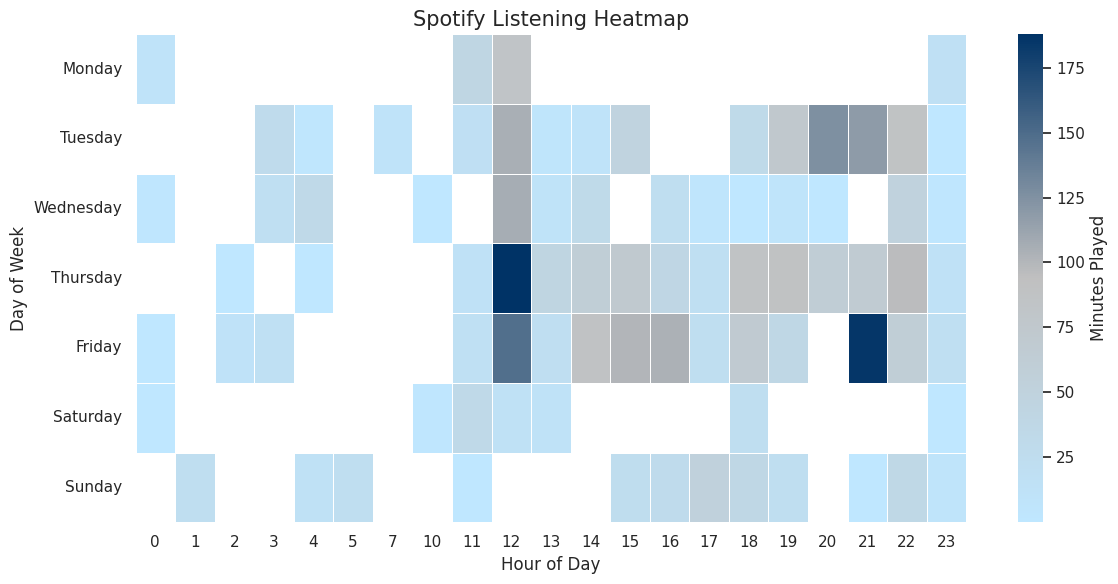

In [24]:
plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    cmap=custom_cmap,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Minutes Played"}
)

plt.title("Spotify Listening Heatmap", fontsize=15)
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.tight_layout()
plt.show()

In [41]:
odu_blue = "#003B8E"
baby_blue = "#9FD6FF"
silver = "#D9D9D9"

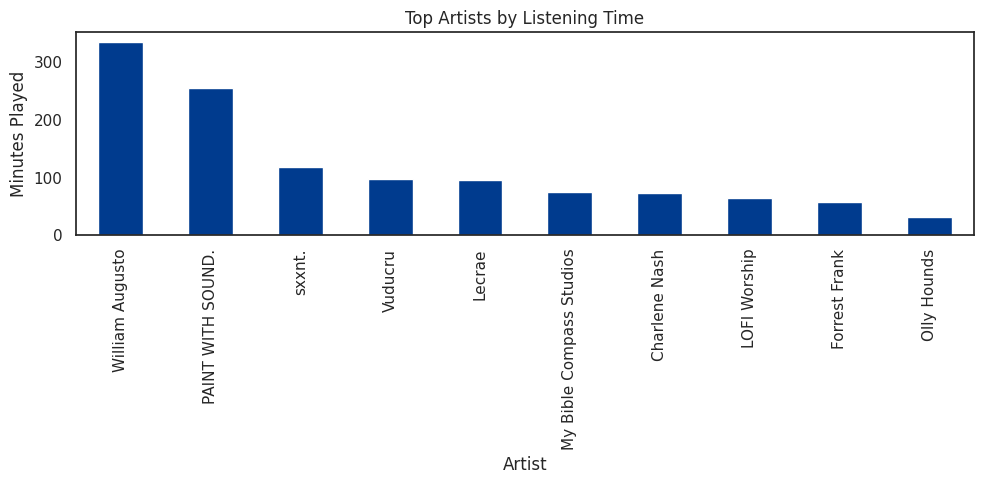

In [38]:
plt.figure(figsize=(10,5))

top_artists.plot(
    kind="bar",
    color=odu_blue
)

plt.title("Top Artists by Listening Time")
plt.ylabel("Minutes Played")
plt.xlabel("Artist")

plt.tight_layout()
plt.show()

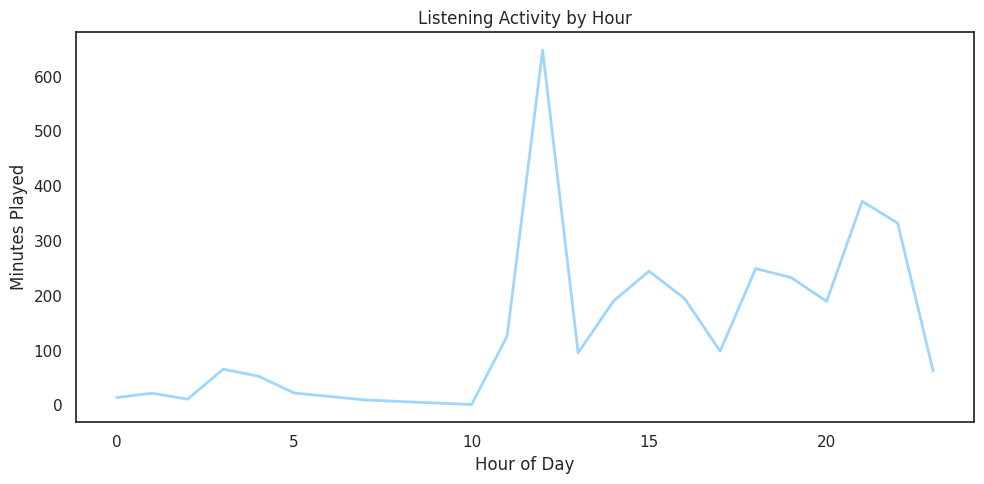

In [39]:
plt.figure(figsize=(10,5))

hourly.plot(color=baby_blue, linewidth=2)

plt.title("Listening Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Minutes Played")

plt.tight_layout()
plt.show()

/tmp/ipykernel_891/2100989959.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly = df.groupby(df["ts"].dt.to_period("M"))["minutes_played"].sum()


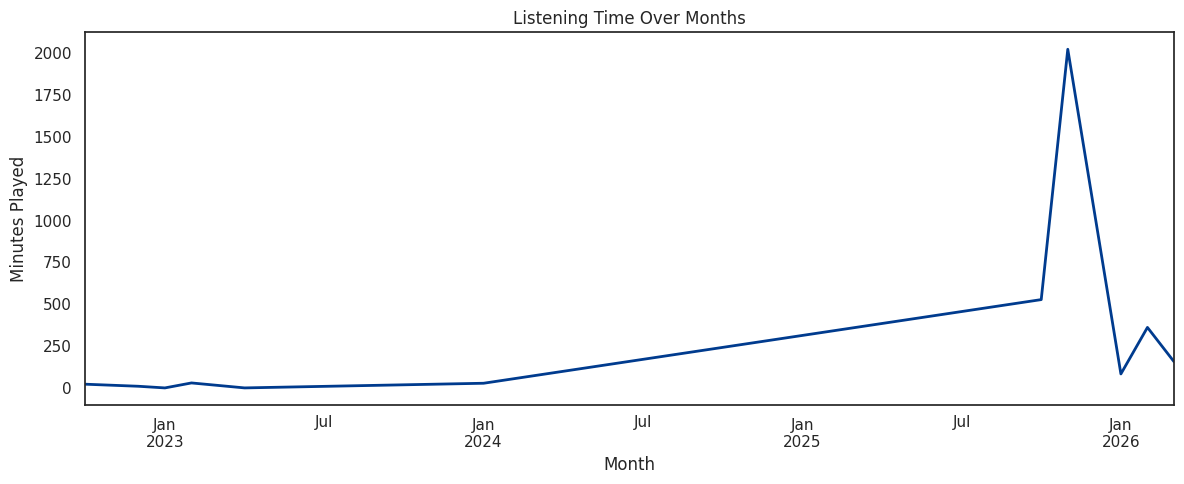

In [37]:
monthly = df.groupby(df["ts"].dt.to_period("M"))["minutes_played"].sum()

plt.figure(figsize=(12,5))

monthly.plot(color=odu_blue, linewidth=2)

plt.title("Listening Time Over Months")
plt.xlabel("Month")
plt.ylabel("Minutes Played")

plt.tight_layout()
plt.show()

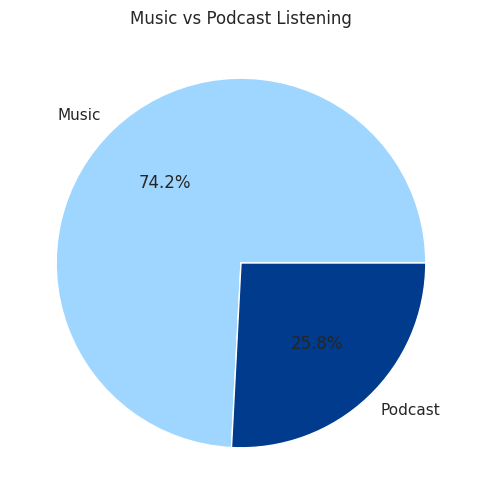

In [40]:
plt.figure(figsize=(6,6))

content.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=[baby_blue, odu_blue]
)

plt.title("Music vs Podcast Listening")
plt.ylabel("")

plt.show()

In [43]:
total_minutes = df["minutes_played"].sum()
total_hours = total_minutes / 60
total_tracks = len(df)

print("Total listening hours:", round(total_hours,2))
print("Total streams:", total_tracks)

Total listening hours: 54.08
Total streams: 1092


In [44]:
top_artist = (
    df.groupby("master_metadata_album_artist_name")["minutes_played"]
    .sum()
    .sort_values(ascending=False)
    .head(1)
)

top_artist

,minutes_played
master_metadata_album_artist_name,
William Augusto,333.944917


In [45]:
top_song = (
    df.groupby("master_metadata_track_name")["minutes_played"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_song

,minutes_played
master_metadata_track_name,
5 Hours of Soaking in His Presence,138.799800
Breakthrough,34.052633
Stress,29.328933
Scherzo No. 5 in Death Minor,25.729683
The Jackal (Mussorgsky Remixed),25.150383
O Fortuna,23.199667
In the Hall of the Mountain King,20.843200
Für Elise (Epic Trailer Version),19.698000
Vivaldi - Original Mix,18.617333


In [46]:
avg_listen = df["minutes_played"].mean()

print("Average listening duration per stream:", round(avg_listen,2), "minutes")

Average listening duration per stream: 2.97 minutes


In [54]:
top_songs = (
    df.groupby("master_metadata_track_name")["minutes_played"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

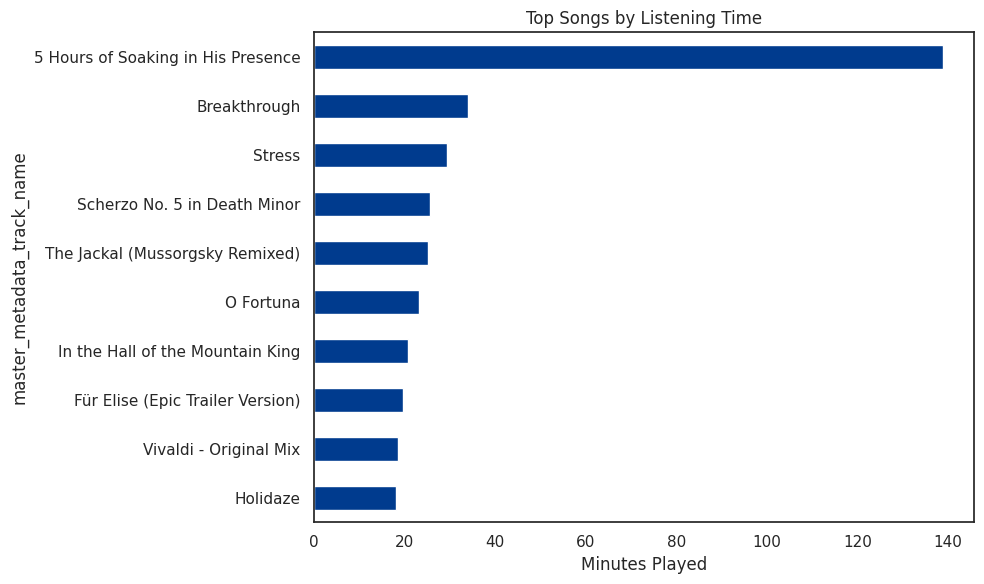

In [56]:
top_songs = top_songs.sort_values()

plt.figure(figsize=(10,6))

top_songs.plot(
    kind="barh",
    color=odu_blue
)

plt.title("Top Songs by Listening Time")
plt.xlabel("Minutes Played")

plt.tight_layout()
plt.show()

## Insights

• Listening activity is concentrated in the evening hours.

• A small number of artists account for a large share of listening time.

• Music dominates listening time compared to podcasts.

• Listening patterns are relatively consistent across months.